# Modeling and Averaging

In this tutorial, we'll use some more tools from `edges-analysis` that help model and average the data.

In [ ]:
from pygsdata import GSData
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
from pygsdata import plots
%matplotlib inline

In [2]:
results = Path("results")

## Read the Data

In [3]:
files = sorted(results.glob("*.singlespec.gsh5"))

In this case, instead of reading each file as a separate gsdata object, let's read all of them together into one object:

In [4]:
data = GSData.from_file(files, concat_axis='time')

Let's also inspect this history of these files:

In [5]:
for stamp in data.history:
    print(f"{stamp.function}:")
    
    for k, v in stamp.parameters.items():
        print(f"\t{k}: {v}")
    print("\n")

read_acq_to_gsdata:
	path: ["tag:yaml.org,2002:python/object/apply:pathlib.PosixPath: [ScalarNode(tag='tag:yaml.org,2002:str', value='/'), ScalarNode(tag='tag:yaml.org,2002:str', value='data5'), ScalarNode(tag='tag:yaml.org,2002:str', value='edges'), ScalarNode(tag='tag:yaml.org,2002:str', value='data'), ScalarNode(tag='tag:yaml.org,2002:str', value='2014_February_Boolardy'), ScalarNode(tag='tag:yaml.org,2002:str', value='mro'), ScalarNode(tag='tag:yaml.org,2002:str', value='low'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016_259_00.acq')]"]


sun_filter:
	elevation_range: (-90, 0)


moon_filter:
	elevation_range: (-90, 20)


dicke_calibration:


approximate_temperature:
	tload: 300
	tns: 1000


average_over_times:
	use_resids: False


rfi_iterative_filter:
	data_modeler: {'max_terms': 37, 'min_terms': 37, 'model': {'_transform': {'range': (45.001220703125, 104.998779296875)}, 'basis_scaler': None, 'data_transform': {}, 'n_t

You can see that each of the processing steps we've applied so far is captured! Let's also make sure that each of the files -- each with one "time" -- is present in the data we've just read:

In [6]:
data.ntimes  # one "time" for each day

3

We want to average these days together, but we must remember that now there are flags in the data. Averaging days together that have different amplitudes (because they have a different mix of LSTs on each) and that have frequency-dependent flags, is going to introduce spectral structure. 

To ameliorate this, we can "inpaint" the data. Instead of actually inserting values in the flag gaps, we can use a method in which we simply keep a model of the data around with the data itself, and when averaging, the averaging function can intelligently use these models to de-bias the average.

## Adding a Model

The `GSData` object has a `.model` and `.residual` attribute which (if they are set at all) should be the same shape as the data. 

You can fill these in whichever way you want -- come up with your own model of the data. However, `edges-analysis` provides some convenient tools for computing models of the data.

In [7]:
from edges import modeling as mdl

You can define a model type:

In [8]:
linlog = mdl.LinLog(n_terms=5)

This model can be directly used to fit any data array:

In [9]:
llfit = linlog.fit(ydata=data.data[0,0,0], xdata=data.freqs, weights=data.flagged_nsamples[0,0,0])

The `llfit` object now has several useful attributes, like the `.residual`:

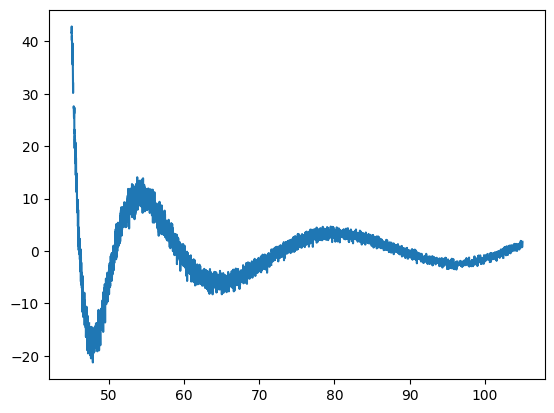

In [10]:
plt.plot(data.freqs, np.where(data.complete_flags[0,0,0], np.nan, llfit.residual))

It also has the set of best-fit parameters:

In [11]:
llfit.model_parameters

(np.float64(1141.2666883518496),
 np.float64(505.65232387258527),
 np.float64(692.9777649142621),
 np.float64(765.3487226405634),
 np.float64(-5344.864264544471))

And also their covariance:

In [12]:
llfit.parameter_covariance

array([[ 1.42474650e-06,  4.16444699e-06, -1.84021443e-05,
        -6.60975331e-05, -4.59051957e-05],
       [ 4.16444699e-06,  1.03743732e-04,  1.04287451e-04,
        -1.21349537e-03, -2.12775435e-03],
       [-1.84021443e-05,  1.04287451e-04,  8.62175833e-04,
         1.26101827e-04, -2.28376758e-03],
       [-6.60975331e-05, -1.21349537e-03,  1.26101827e-04,
         2.07015074e-02,  3.29720401e-02],
       [-4.59051957e-05, -2.12775435e-03, -2.28376758e-03,
         3.29720401e-02,  6.10921719e-02]])

Importantly for us, there is an easy way to add such a model to our `GSData` object:

In [13]:
from edges.analysis.datamodel import add_model

In [14]:
data = add_model(data, model=linlog)

Now we have access to the residuals:

In [15]:
data.residuals

array([[[[ 4.99449327e+01,  4.81488097e+01,  4.48224864e+01, ...,
           1.54636736e+00,  1.74993694e+00,  1.75943627e+00],
         [ 4.92231461e+01,  4.91628398e+01,  4.96947915e+01, ...,
           1.39380229e+00,  1.75865473e+00,  1.54328441e+00],
         [ 4.46104264e+01,  4.73151725e+01,  5.12853374e+01, ...,
           2.33202770e+00,  1.25408837e+00, -2.08452273e-02]]]],
      shape=(1, 1, 3, 9831))

In fact, let's plot all the residuals in the data:

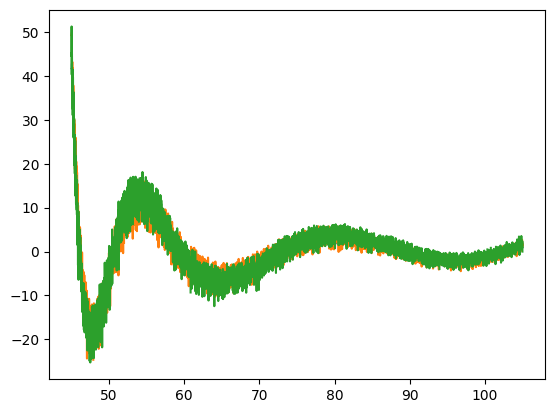

In [16]:
for x in data.time_iter():
    plt.plot(
        data.freqs, 
        np.where(data.complete_flags[x], np.nan, data.residuals[x]).flatten()
    )

Note that these residuals are at about 10K!! This is because we've only *roughly* calibrated the data. We don't want to get into calibration (which is very experiment-specific) in this tutorial. Suffice to say that `edges.cal` has methods for applying EDGES-style calibration. 

## Time-Averaging

Now that we have model residuals, we can try to safely average these three nights together.

In [17]:
from edges.averaging import average_over_times

By _default_ if model residulas are present in the data object, the `average_over_times` function will use them to inpaint while averaging.

In [18]:
avg_data = average_over_times(data, fill_value=np.nan)

/data4/vydula/edges/packages/edges3-data-analysis/.venv/lib/python3.13/site-packages/edges/averaging/lstbin.py:101: RuntimeWarning: invalid value encountered in divide
  mean_resids = sum_resids / ntot


Now let's plot our averaged spectrum:

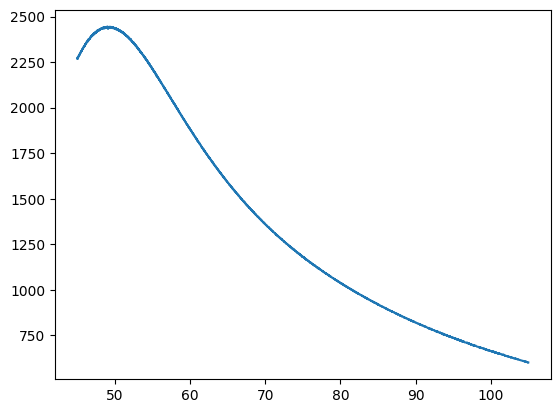

In [19]:
plt.plot(data.freqs, avg_data.data.flatten())

Note that we no longer have to fill in the flagged values with `nan` explicitly when making the plot. This is because when averaging, the averaging routine _uses_ the existing flags to inform the `nsamples` of the output averaged data, and then sets all Flags back to False. Thus, in the average, the RFI should be totally gone (we've "lost" that information). On the other hand, channels that have no good samples on any night must get a value to fill in, and here we've explicitly asked for that to be `nan`, which makes this plot look nice (the default is zero). 

We can also plot the resulting averaged residauls:

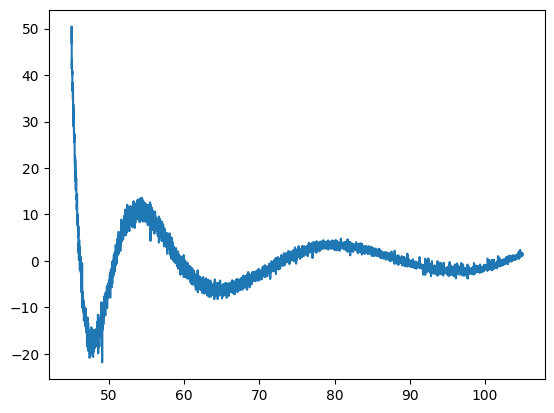

In [20]:
plt.plot(data.freqs, avg_data.residuals.flatten())

## Average frequency channels together

To reduce noise on this plot, we can also average together neighbouring channels:

In [21]:
from edges.averaging import freq_bin

In [22]:
freq_avg_data = freq_bin(avg_data, bins=16) # 16 channels per bin. 

The resulting object has residuals (averaged from the previous residuals) but it is probably worth fitting again:

In [23]:
freq_avg_data = add_model(freq_avg_data, model=linlog)

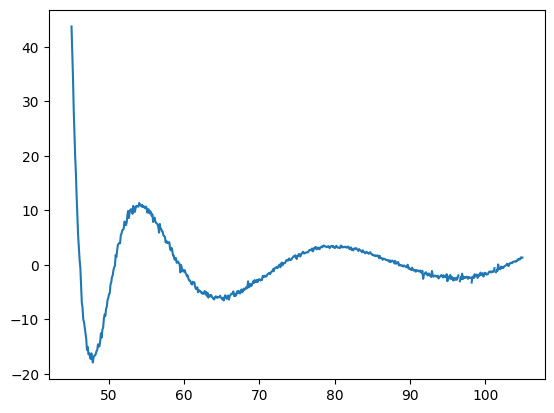

In [24]:
plt.plot(freq_avg_data.freqs, freq_avg_data.residuals.flatten())

### Simple Foreground model fit on LST binned data

For data binned in LST, we can use `pygsdata.plots` to plot the residuals in each LST bin, computed using `.model`.

For this, we will use the filtered data from previous notebook. Recall that filtered data is after the filters of galaxy-down, sun-down and moon-down conditions have been applied. 



In [39]:
filtered_data = GSData.from_file(results / "2016-259.filtered.gsh5")

We can check how many LST bins are present in data after the Galaxy, sun and moon filter were applied in the previous notebook. 

In [41]:
filtered_data.lsts

<Longitude [[7.39866325],
            [7.40924771],
            [7.4201107 ],
            ...,
            [7.42649187],
            [7.43735486],
            [7.44821786]] hourangle>

Note that the data is not binned in LST. So we will bin the data in 30 min bins. 

In [64]:
from edges.averaging import lst_bin 
lstbin_params = {    
    "binsize": 0.5,
    'first_edge': 0,
    'max_edge': 12,
    'use_model_residuals': False,
    'in_gha': False,
}

In [65]:


lstbin_data = lst_bin(
    filtered_data, **lstbin_params
)

/data4/vydula/edges/packages/edges3-data-analysis/.venv/lib/python3.13/site-packages/pygsdata/register.py:44: UserWarning: Auxiliary measurements cannot be binned!
  newdata = func(data, *args, **kw)


As we did for the singlespec data, we will now add model for this data. 

In [66]:
lstbin_data = add_model(data=lstbin_data, model=linlog)

In [67]:
lstbin_data.lsts

<Longitude [[ 0.25],
            [ 0.75],
            [ 1.25],
            [ 1.75],
            [ 2.25],
            [ 2.75],
            [ 3.25],
            [ 3.75],
            [ 4.25],
            [ 4.75],
            [ 5.25],
            [ 5.75],
            [ 6.25],
            [ 6.75],
            [ 7.25],
            [ 7.75],
            [ 8.25],
            [ 8.75],
            [ 9.25],
            [ 9.75],
            [10.25],
            [10.75],
            [11.25],
            [11.75]] hourangle>

There are a total of 24 0.5 hr bins, however not all bins have data. 

(array([<Axes: title={'center': 'Residuals for all LSTs'}, xlabel='Frequency (MHz)', ylabel='Residuals (K)'>,
        <Axes: xlabel='LST (hr)', ylabel='RMS (K)'>], dtype=object),
 <matplotlib.colorbar.Colorbar at 0x7f731c426e90>)

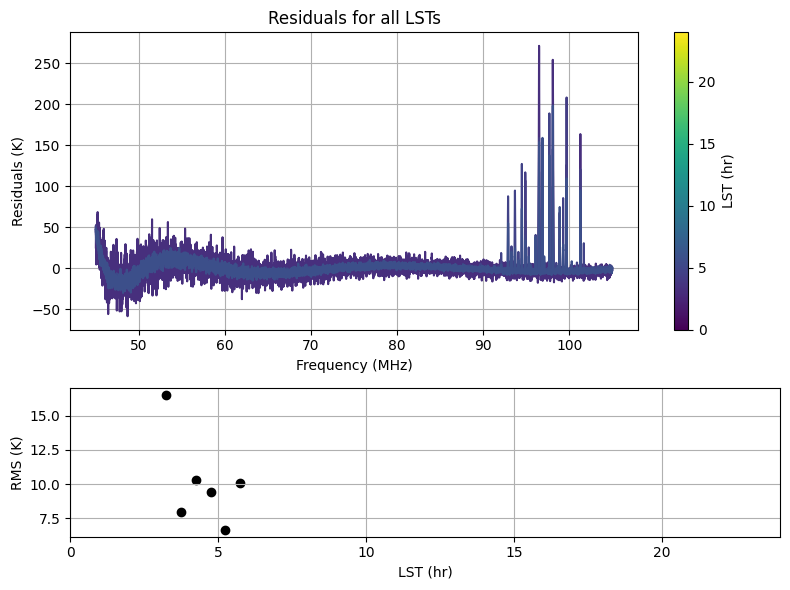

In [62]:
plots.plot_model_residuals_vs_lst(lstbin_data)


And there you have it! As far as we can go with our current simplified analysis. 

There are many more features of `edges-analysis` that you might want to check out with your own data as well.